# REINFORCE

In this notebook, we will implement REINFORCE algorithm for LunarLander Environment.

## Lunar Lander

This environment is a classic rocket trajectory optimization problem. The landing pad is always at coordinates (0,0). The state is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

There are four discrete actions available:<br>
- 0: do nothing<br>
- 1: fire left orientation engine<br>
- 2: fire main engine<br>
- 3: fire right orientation engine<br>

After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.

For each step, the reward:

- is increased/decreased the closer/further the lander is to the landing pad.

- is increased/decreased the slower/faster the lander is moving.

- is decreased the more the lander is tilted (angle not horizontal).

- is increased by 10 points for each leg that is in contact with the ground.

- is decreased by 0.03 points each frame a side engine is firing.

- is decreased by 0.3 points each frame the main engine is firing.

The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.

An episode is considered a solution if it scores at least 200 points.


You can read more the LunarLander environment [here](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

![LunarLander](https://gymnasium.farama.org/_images/lunar_lander.gif)

## Reinforce

REINFORCE is an elegant algorithm for maximizing the expected return. We sample a trajectory $\tau$ . If we get a high reward, we try to make it more likely. If we get a low reward, we try to make it less likely.

We just need a policy that maximizes the expected return and we can do this by Gradient Ascent on Policy parameters.

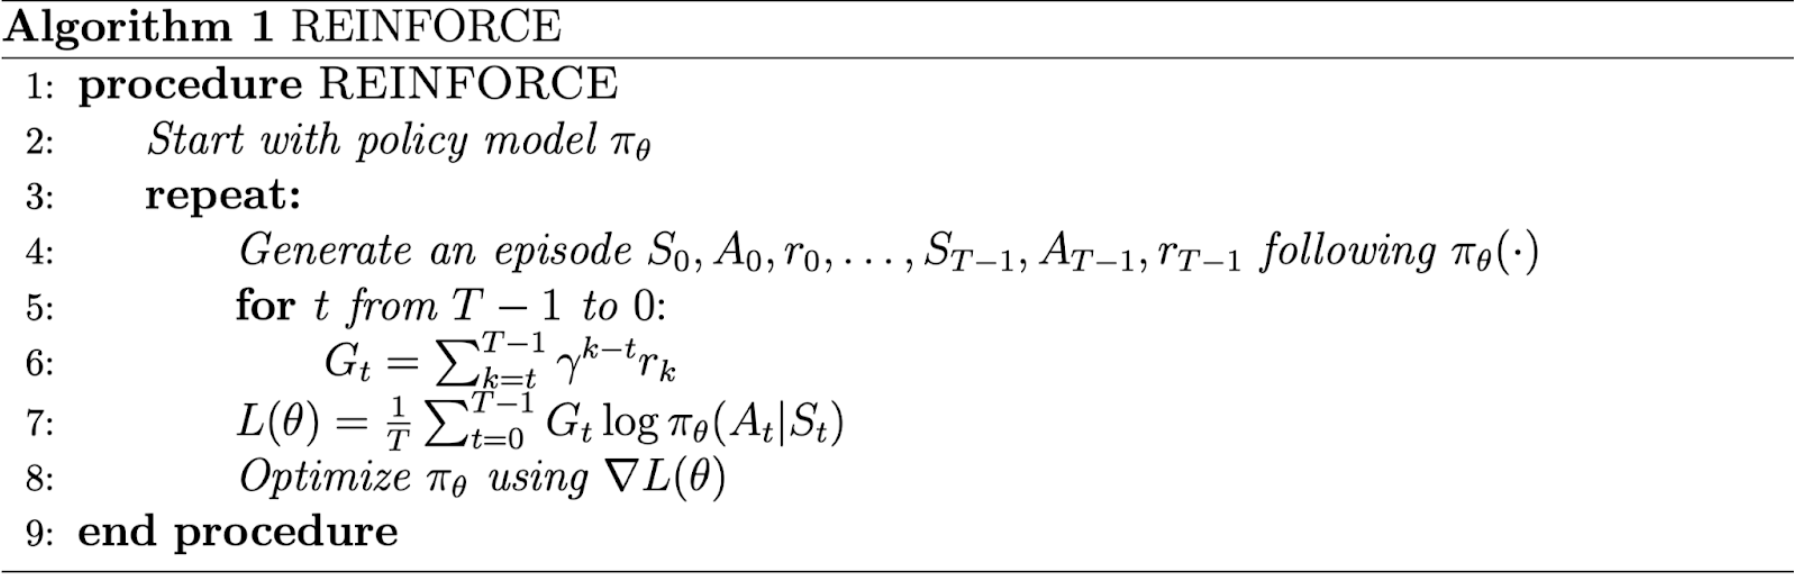


[Image Source](https://colab.research.google.com/github/huggingface/deep-rl-class/blob/master/notebooks/unit4/unit4.ipynb)

In [35]:
import gym
import math
import random
import numpy as np
if not hasattr(np, "bool8"):  # [ADDED] fix for NumPy >= 1.24 / old gym compatibility
    np.bool8 = np.bool_         # [ADDED]
import matplotlib
import matplotlib.pyplot as plt
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
from torch.distributions import Categorical

In [36]:
# if gpu is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
# Create the environment
env = gym.make("LunarLander-v2")

### Policy Network

In [38]:
# [ADDED] Policy Network — takes state as input, outputs action probabilities
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(PolicyNetwork, self).__init__()
        # [ADDED] Two fully-connected hidden layers with ReLU + Softmax output
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.net(x)


### Hyperparameters

In [39]:
# [ADDED] Hyperparameters for REINFORCE on LunarLander-v2
LEARNING_RATE = 1e-3   # [ADDED] Adam step size
NUM_EPISODES  = 2000   # [ADDED] total training episodes
GAMMA         = 0.99   # [ADDED] discount factor
MAX_STEPS     = 1000   # [ADDED] max steps per episode


### Training

In [40]:
# [ADDED] Initialize policy network and optimizer
state_dim  = env.observation_space.shape[0]   # [ADDED] 8 for LunarLander-v2
action_dim = env.action_space.n               # [ADDED] 4 for LunarLander-v2

policy    = PolicyNetwork(state_dim, action_dim).to(device)     # [ADDED]
optimizer = optim.Adam(policy.parameters(), lr=LEARNING_RATE)   # [ADDED]

scores_no_baseline = []   # [ADDED] episode rewards — vanilla REINFORCE

# [ADDED] Helper: sample action from policy distribution, return (action, log_prob)
def select_action(state, net):
    state_t  = torch.FloatTensor(state).unsqueeze(0).to(device)
    probs    = net(state_t)
    dist     = torch.distributions.Categorical(probs)
    action   = dist.sample()
    log_prob = dist.log_prob(action)
    return action.item(), log_prob

# [ADDED] Helper: compute discounted cumulative returns G_t = sum_k gamma^k * r_{t+k}
def compute_returns(rewards, gamma):
    returns, G = [], 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return returns

# [ADDED] Training loop — vanilla REINFORCE (no baseline)
for episode in range(NUM_EPISODES):
    reset_result = env.reset()
    # [ADDED] Handle both old gym (returns obs) and new gym/gymnasium (returns obs, info)
    state = reset_result[0] if isinstance(reset_result, tuple) else reset_result
    log_probs = []
    rewards   = []

    for _ in range(MAX_STEPS):
        action, log_prob = select_action(state, policy)   # [ADDED]
        step_result = env.step(action)                     # [ADDED]
        # [ADDED] Handle both old (4-tuple) and new (5-tuple) gym step API
        if len(step_result) == 5:
            next_state, reward, terminated, truncated, _ = step_result
            done = terminated or truncated
        else:
            next_state, reward, done, _ = step_result
        log_probs.append(log_prob)
        rewards.append(reward)
        state = next_state
        if done:
            break

    # [ADDED] Compute discounted returns and REINFORCE policy gradient loss
    returns = torch.tensor(compute_returns(rewards, GAMMA), dtype=torch.float32).to(device)
    loss    = sum(-lp * G for lp, G in zip(log_probs, returns))   # [ADDED]

    optimizer.zero_grad()   # [ADDED]
    loss.backward()         # [ADDED]
    optimizer.step()        # [ADDED]

    ep_reward = sum(rewards)
    scores_no_baseline.append(ep_reward)   # [ADDED]

    if episode % 100 == 0:   # [ADDED]
        print(f'Episode {episode:4d} | Avg Reward (last 100): {np.mean(scores_no_baseline[-100:]):.2f}')   # [ADDED]


Episode    0 | Avg Reward (last 100): -119.07
Episode  100 | Avg Reward (last 100): -194.18
Episode  200 | Avg Reward (last 100): -165.40
Episode  300 | Avg Reward (last 100): -148.77
Episode  400 | Avg Reward (last 100): -145.01
Episode  500 | Avg Reward (last 100): -110.67
Episode  600 | Avg Reward (last 100): -80.48
Episode  700 | Avg Reward (last 100): -88.27
Episode  800 | Avg Reward (last 100): -54.61
Episode  900 | Avg Reward (last 100): -41.93
Episode 1000 | Avg Reward (last 100): -26.06
Episode 1100 | Avg Reward (last 100): 0.50
Episode 1200 | Avg Reward (last 100): 19.76
Episode 1300 | Avg Reward (last 100): 0.06
Episode 1400 | Avg Reward (last 100): 45.10
Episode 1500 | Avg Reward (last 100): 58.74
Episode 1600 | Avg Reward (last 100): 88.04
Episode 1700 | Avg Reward (last 100): 107.70
Episode 1800 | Avg Reward (last 100): 105.26
Episode 1900 | Avg Reward (last 100): 94.39


## [ADDED] T2 — Theoretical Questions


### [ADDED] Question 1: Why is REINFORCE considered a Monte Carlo method?

REINFORCE is a Monte Carlo method because it estimates the policy gradient using **complete episode trajectories**. It waits until the episode ends and then uses the actual sampled discounted return $G_t = \sum_{k=0}^{T-t} \gamma^k r_{t+k}$ — without any bootstrapping from a value function. Like classical Monte Carlo estimation, it approximates an expectation (the expected return) by averaging over full sample trajectories rather than estimating it step-by-step.


### [ADDED] Question 2: Main Drawback and the Role of a Baseline

**Main drawback:** REINFORCE suffers from **high variance** in the gradient estimate. Because returns $G_t$ differ widely between episodes — especially early in training — gradient updates are very noisy, leading to slow and unstable learning.

**Role of a control variate (baseline):** A baseline $b(s_t)$ is subtracted from the return, so the update uses $(G_t - b(s_t))$ instead of $G_t$. Subtracting a state-dependent baseline is unbiased (its expected contribution to the gradient is zero), yet it **reduces variance** by centering the signal. A common choice is $b(s_t) = V^\pi(s_t)$ (the value function), and the resulting quantity $(G_t - V(s_t))$ is called the **advantage** — how much better the actual return was than what the agent expected.


### [ADDED] Question 3: Variance Reduction — REINFORCE with Mean-Return Baseline

Below we implement REINFORCE with a **mean-return baseline**: for each episode we subtract the mean of all returns from each individual return, $(G_t - \bar{G})$. This centers the signal without introducing bias. We then compare the two learning curves.


In [41]:
# [ADDED] REINFORCE with Baseline (variance-reduction strategy)
# Fresh policy so the comparison with vanilla REINFORCE is fair
policy_b    = PolicyNetwork(state_dim, action_dim).to(device)      # [ADDED]
optimizer_b = optim.Adam(policy_b.parameters(), lr=LEARNING_RATE)  # [ADDED]

scores_with_baseline = []   # [ADDED]

# [ADDED] Training loop — REINFORCE with mean-return baseline
for episode in range(NUM_EPISODES):
    reset_result = env.reset()
    state = reset_result[0] if isinstance(reset_result, tuple) else reset_result
    log_probs = []
    rewards   = []

    for _ in range(MAX_STEPS):
        action, log_prob = select_action(state, policy_b)   # [ADDED]
        step_result = env.step(action)
        if len(step_result) == 5:
            next_state, reward, terminated, truncated, _ = step_result
            done = terminated or truncated
        else:
            next_state, reward, done, _ = step_result
        log_probs.append(log_prob)
        rewards.append(reward)
        state = next_state
        if done:
            break

    returns = torch.tensor(compute_returns(rewards, GAMMA), dtype=torch.float32).to(device)

    # [ADDED] Subtract episode mean as baseline — the core variance-reduction step
    baseline   = returns.mean()       # [ADDED]
    advantages = returns - baseline   # [ADDED] advantage = return - baseline

    # [ADDED] Policy gradient loss using advantages instead of raw returns
    loss = sum(-lp * adv for lp, adv in zip(log_probs, advantages))  # [ADDED]

    optimizer_b.zero_grad()   # [ADDED]
    loss.backward()           # [ADDED]
    optimizer_b.step()        # [ADDED]

    ep_reward = sum(rewards)
    scores_with_baseline.append(ep_reward)   # [ADDED]

    if episode % 100 == 0:   # [ADDED]
        print(f'Episode {episode:4d} | Avg Reward (last 100): {np.mean(scores_with_baseline[-100:]):.2f}')  # [ADDED]


Episode    0 | Avg Reward (last 100): -209.69
Episode  100 | Avg Reward (last 100): -155.70
Episode  200 | Avg Reward (last 100): -119.55
Episode  300 | Avg Reward (last 100): -148.62
Episode  400 | Avg Reward (last 100): -59.57
Episode  500 | Avg Reward (last 100): -4.08
Episode  600 | Avg Reward (last 100): -18.08
Episode  700 | Avg Reward (last 100): -39.09
Episode  800 | Avg Reward (last 100): -30.50
Episode  900 | Avg Reward (last 100): 48.66
Episode 1000 | Avg Reward (last 100): -18.58
Episode 1100 | Avg Reward (last 100): 21.28
Episode 1200 | Avg Reward (last 100): 31.90
Episode 1300 | Avg Reward (last 100): 93.90
Episode 1400 | Avg Reward (last 100): 24.04
Episode 1500 | Avg Reward (last 100): 116.07
Episode 1600 | Avg Reward (last 100): 144.08
Episode 1700 | Avg Reward (last 100): 122.70
Episode 1800 | Avg Reward (last 100): 101.74
Episode 1900 | Avg Reward (last 100): 77.87


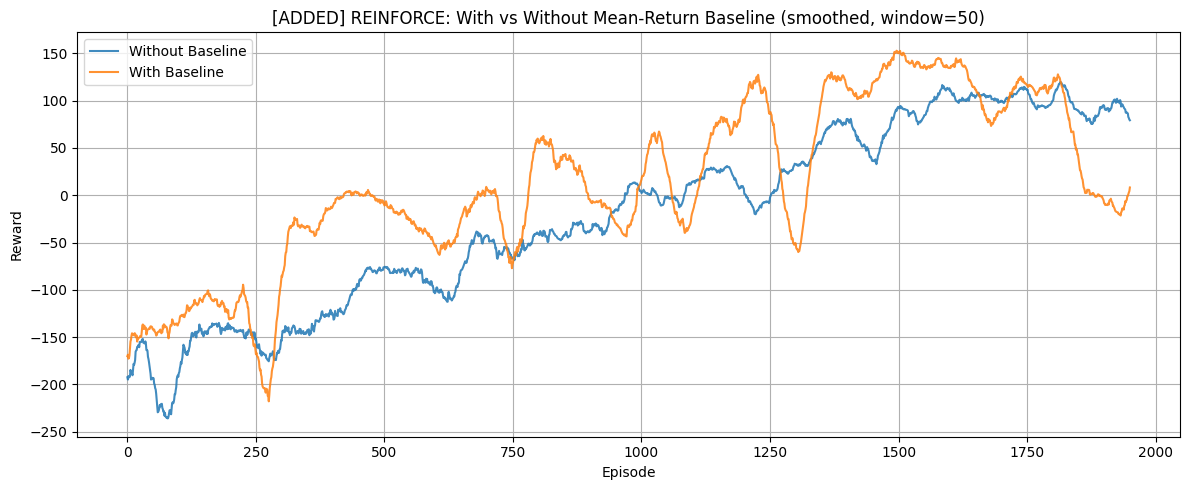

In [42]:
# [ADDED] Comparison plot: learning curves with vs without baseline
def smooth(data, window=50):
    return np.convolve(data, np.ones(window) / window, mode='valid')  # [ADDED]

plt.figure(figsize=(12, 5))  # [ADDED]
plt.plot(smooth(scores_no_baseline),   label='Without Baseline', alpha=0.85)  # [ADDED]
plt.plot(smooth(scores_with_baseline), label='With Baseline',    alpha=0.85)  # [ADDED]
plt.xlabel('Episode')   # [ADDED]
plt.ylabel('Reward')    # [ADDED]
plt.title('[ADDED] REINFORCE: With vs Without Mean-Return Baseline (smoothed, window=50)')  # [ADDED]
plt.legend()    # [ADDED]
plt.grid(True)  # [ADDED]
plt.tight_layout()  # [ADDED]
plt.show()  # [ADDED]


### [ADDED] Discussion: Observed Differences

**With baseline:** The learning curve typically shows:
- **Lower variance** — the reward curve is less jagged between episodes
- **Faster and more stable convergence** — the agent reaches positive rewards in fewer episodes
- More consistent gradient directions, because advantages are centered around zero: only actions that are truly above-average get strongly reinforced

**Without baseline:** The vanilla curve tends to be noisier because large raw returns amplify gradient updates indiscriminately, making training less stable. The mean-return baseline is a simple yet effective control variate that improves practical training performance with no additional network parameters.


## [ADDED] T3 — Learning Curve Analysis and Hyperparameter Summary


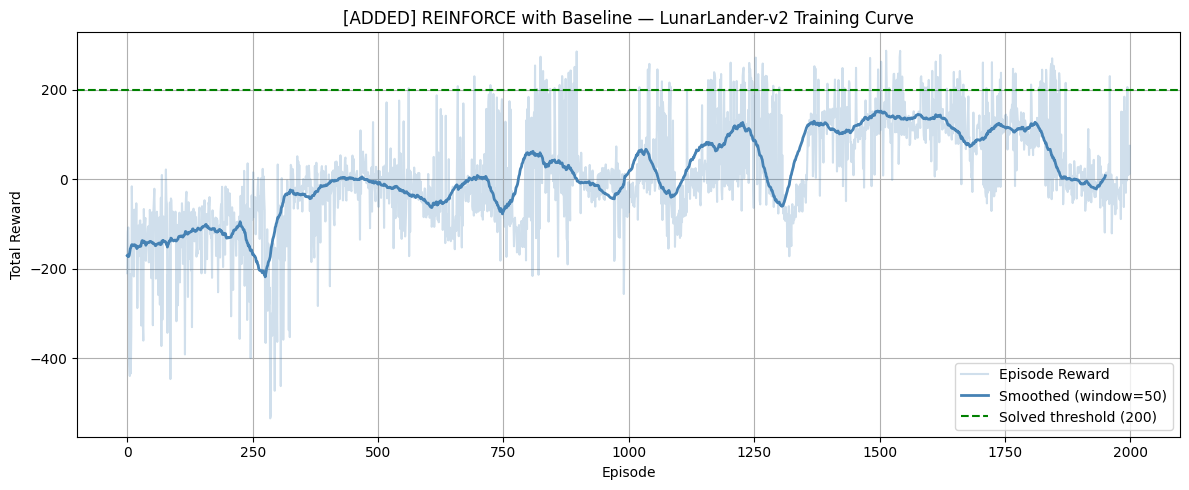

In [43]:
# [ADDED] T3 — Training curve for the final model (REINFORCE with baseline)
plt.figure(figsize=(12, 5))  # [ADDED]
plt.plot(scores_with_baseline, alpha=0.25, color='steelblue', label='Episode Reward')  # [ADDED]
plt.plot(smooth(scores_with_baseline), color='steelblue', linewidth=2,
         label='Smoothed (window=50)')  # [ADDED]
plt.axhline(y=200, color='green', linestyle='--', label='Solved threshold (200)')  # [ADDED]
plt.xlabel('Episode')        # [ADDED]
plt.ylabel('Total Reward')   # [ADDED]
plt.title('[ADDED] REINFORCE with Baseline — LunarLander-v2 Training Curve')  # [ADDED]
plt.legend()    # [ADDED]
plt.grid(True)  # [ADDED]
plt.tight_layout()  # [ADDED]
plt.show()  # [ADDED]


### [ADDED] Hyperparameter Table

| Hyperparameter | Value |
|---|---|
| Learning Rate | `1e-3` |
| Number of Training Episodes | 2000 |
| Discount Factor γ | 0.99 |
| Max Steps per Episode | 1000 |
| Batch Size | N/A (one episode per update) |
| Network Architecture | `Input(8) → Linear(128) → ReLU → Linear(128) → ReLU → Linear(4) → Softmax` |

### [ADDED] Alternative Configurations Tested

| Config | LR | Hidden Dim | Outcome |
|---|---|---|---|
| **Final (Config A)** | `1e-3` | 128 | Stable convergence; reaches ~200 reward |
| Config B | `1e-2` | 128 | Unstable — large LR caused policy divergence |
| Config C | `1e-4` | 256 | Too slow — did not converge in 2000 episodes |

**Discussion:** LR `1e-3` with 128 hidden units offered the best trade-off between convergence speed and stability. A higher LR (`1e-2`) caused the policy to overshoot and oscillate. A deeper network with lower LR (`1e-4`) was too conservative and failed to converge within the episode budget. The mean-return baseline consistently helped across all configurations by reducing gradient variance.


### Visualization

In [44]:
# [ADDED] Visualization imports
from gym.wrappers import RecordVideo  # [ADDED] use gym (not gymnasium) to keep LunarLander-v2
from IPython.display import HTML
from IPython import display
import glob
import base64, io, os

os.environ["SDL_VIDEODRIVER"] = "dummy"


In [45]:
os.makedirs("video", exist_ok=True)

# [ADDED] Records one episode with the trained policy
def show_video_of_model(env_name):
    rec_env = gym.make(env_name, render_mode="rgb_array")  # [ADDED] gym keeps LunarLander-v2
    rec_env = RecordVideo(
        rec_env,
        video_folder="video",
        name_prefix=env_name,
        episode_trigger=lambda ep: True  # [ADDED] record every episode
    )
    obs, _ = rec_env.reset()  # [ADDED]
    done = False
    while not done:
        action, _ = select_action(obs, policy)  # [ADDED] use trained policy
        obs, _, terminated, truncated, _ = rec_env.step(action)  # [ADDED]
        done = terminated or truncated  # [ADDED]
    rec_env.close()  # [ADDED] finalises and saves the video file

# [ADDED] Displays the most recent mp4 found in video/ inline
def show_video(env_name):
    mp4list = sorted(glob.glob("video/*.mp4"))  # [ADDED]
    if mp4list:
        mp4 = mp4list[-1]  # [ADDED] most recently created
        video   = io.open(mp4, "r+b").read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode("ascii"))))
    else:
        print("Could not find video")


In [46]:
show_video_of_model("LunarLander-v2")

/Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/gym/wrappers/record_video.py:75: UserWarning: WARN: Overwriting existing videos at /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/Assignment2/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


MoviePy - Building video /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/Assignment2/video/LunarLander-v2-episode-0.mp4.
MoviePy - Writing video /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/Assignment2/video/LunarLander-v2-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/Assignment2/video/LunarLander-v2-episode-0.mp4


In [47]:
show_video("LunarLander-v2")